In [37]:
import os
import numpy as np
import pywt
from scipy.signal import butter, sosfilt, resample
import matplotlib.pyplot as plt

from mne.datasets import sample
from mne_bids import (
    BIDSPath,
    find_matching_paths,
    get_entity_vals,
    make_report,
    print_dir_tree,
    read_raw_bids,
)

In [2]:
bids_path = BIDSPath(root="./example_sub", subject="aaaaaaar", session="s0022006", task="rest", processing="02tcple", datatype="eeg", extension=".edf", recording="t001")

In [3]:
raw = read_raw_bids(bids_path=bids_path, verbose=False)

In [4]:
print(raw.info)

<Info | 12 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, A1, A2, P3, P4, O1, O2, F7, F8, T3, ...
 chs: 21 EEG
 custom_ref_applied: False
 description: Anonymized using a time shift to preserve age at acquisition
 dig: 24 items (3 Cardinal, 21 EEG)
 experimenter: mne_anonymize
 highpass: 0.0 Hz
 line_freq: 60.0
 lowpass: 125.0 Hz
 meas_date: 2006-01-01 00:00:00 UTC
 nchan: 21
 projs: []
 sfreq: 250.0 Hz
 subject_info: 3 items (dict)
>


In [6]:
data = raw.get_data()
print(data.shape)

(21, 152250)


In [95]:
delta_filter = butter(4, [0.1, 4], btype="bandpass", fs=raw.info["sfreq"], output="sos")
theta_filter = butter(4, [4, 8], btype="bandpass", fs=raw.info["sfreq"], output="sos")
alpha_filter = butter(4, [8, 13], btype="bandpass", fs=raw.info["sfreq"], output="sos")
beta_filter = butter(4, [13, 30], btype="bandpass", fs=raw.info["sfreq"], output="sos")
gamma_filter = butter(4, [30, 100], btype="bandpass", fs=raw.info["sfreq"], output="sos")
high_filter = butter(4, 100, btype="highpass", fs=raw.info["sfreq"], output="sos")

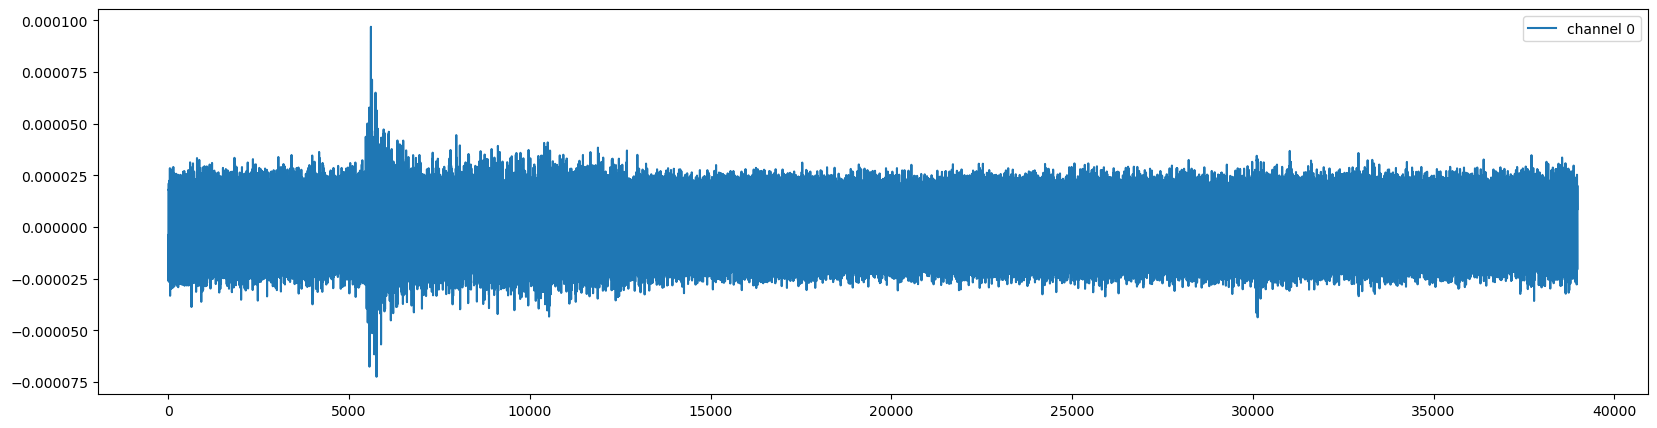

In [96]:
plt.figure(figsize=(20, 5))
for i in range(1):
	plt.plot(data[i, :], label=f'channel {i}')
plt.legend()
plt.show()

In [97]:
delta_data = sosfilt(delta_filter, data[0], axis=-1)
beta_data = sosfilt(beta_filter, data[0], axis=-1)
alpha_data = sosfilt(alpha_filter, data[0], axis=-1)
theta_data = sosfilt(theta_filter, data[0], axis=-1)
gamma_data = sosfilt(gamma_filter, data[0], axis=-1)
high_data = sosfilt(high_filter, data[0], axis=-1)
print(delta_data.shape, beta_data.shape, alpha_data.shape, theta_data.shape, gamma_data.shape, high_data.shape)

(38979,) (38979,) (38979,) (38979,) (38979,) (38979,)


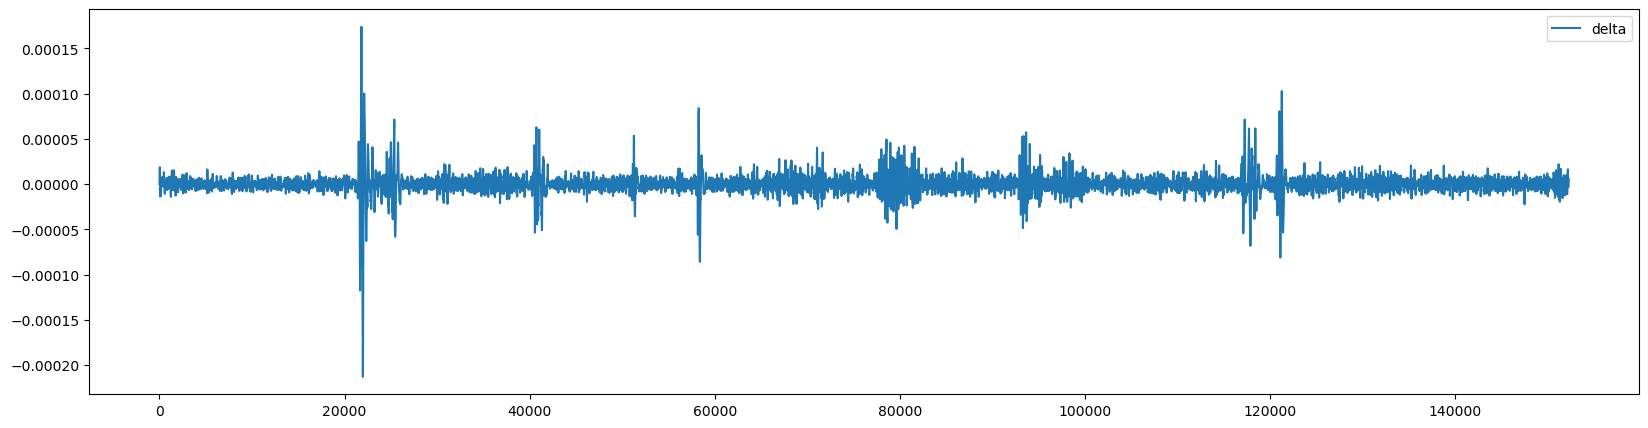

In [93]:
plt.figure(figsize=(20, 5))
plt.plot(delta_data, label='delta')
#plt.plot(theta_data, label='theta')
#plt.plot(alpha_data, label='alpha')
#plt.plot(beta_data, label='beta')
#plt.plot(gamma_data, label='gamma')
#plt.plot(high_data, label='high')
plt.legend()
plt.show()

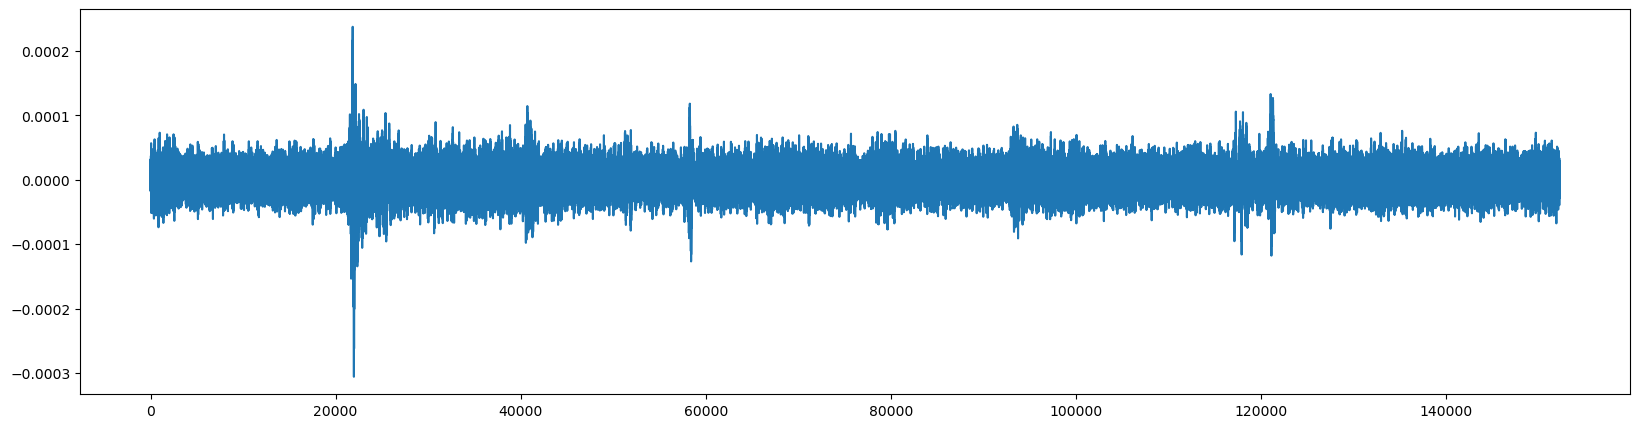

In [36]:
plt.figure(figsize=(20, 5))
reconstructed_signal = delta_data + theta_data + alpha_data + beta_data + gamma_data + high_data
plt.plot(reconstructed_signal, label='reconstructed')
plt.show()

In [38]:
raw_downsampled = raw.copy().resample(sfreq=128)
data_downsampled = raw_downsampled.get_data()

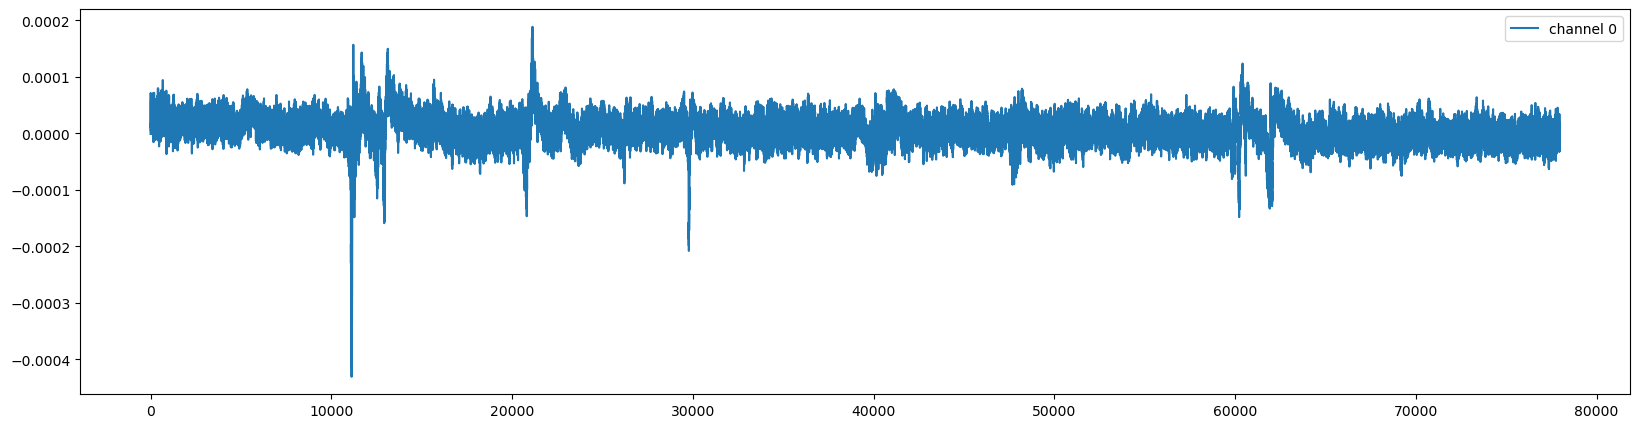

In [39]:
plt.figure(figsize=(20, 5))
for i in range(1):
	plt.plot(data_downsampled[i, :], label=f'channel {i}')
plt.legend()
plt.show()

In [40]:
dbt = pywt.WaveletPacket(data_downsampled, wavelet='db4', maxlevel=5, axis=-1)

In [43]:
relevant_bands = {
	'delta': dbt['aaaaa'].data,
	'theta': dbt['aaaad'].data,
	'alpha': dbt['aaad'].data,
	'beta': dbt['aad'].data,
	'gamma': dbt['ad'].data,
	'high_freq': dbt['d'].data
}

for band, data in relevant_bands.items():
	print(band, data.shape)

delta (21, 2442)
theta (21, 2442)
alpha (21, 4878)
beta (21, 9750)
gamma (21, 19493)
high_freq (21, 38979)


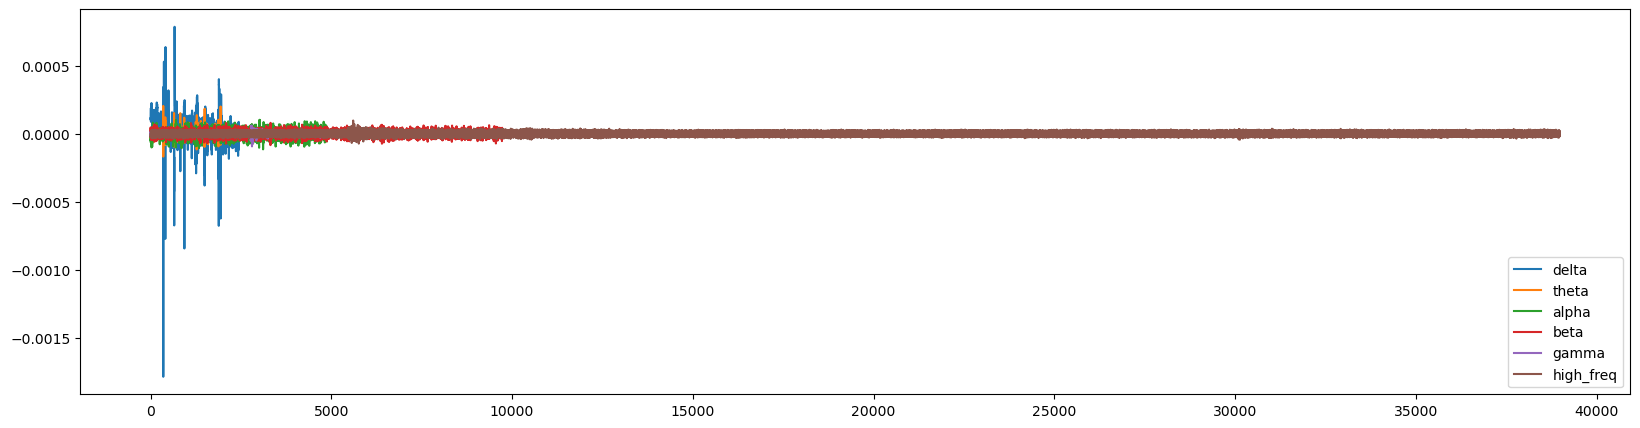

In [45]:
plt.figure(figsize=(20, 5))
for band, data in relevant_bands.items():
	plt.plot(data[0], label=band)
plt.legend()
plt.show()

In [62]:
wavelet_recon = pywt.waverec([relevant_bands['delta'], relevant_bands['theta'], relevant_bands['alpha'], relevant_bands['beta'], relevant_bands['gamma']], wavelet='db4', axis=-1)
print(wavelet_recon.shape)

(21, 38980)


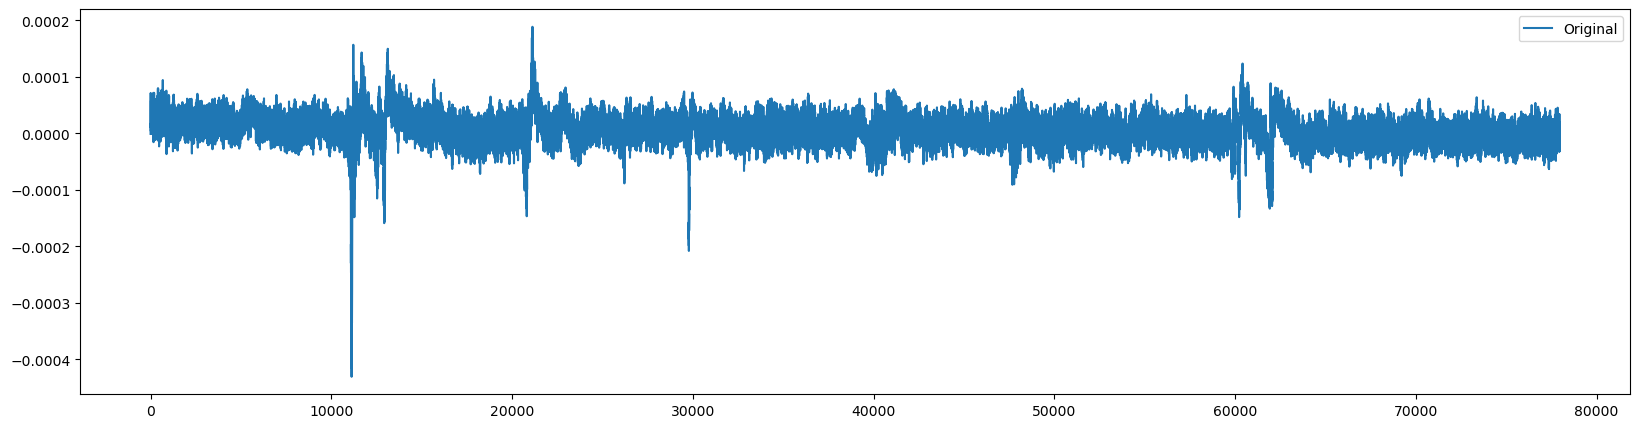

In [60]:
plt.figure(figsize=(20, 5))
plt.plot(data_downsampled[0, :], label=f'Original')
plt.legend()
plt.show()

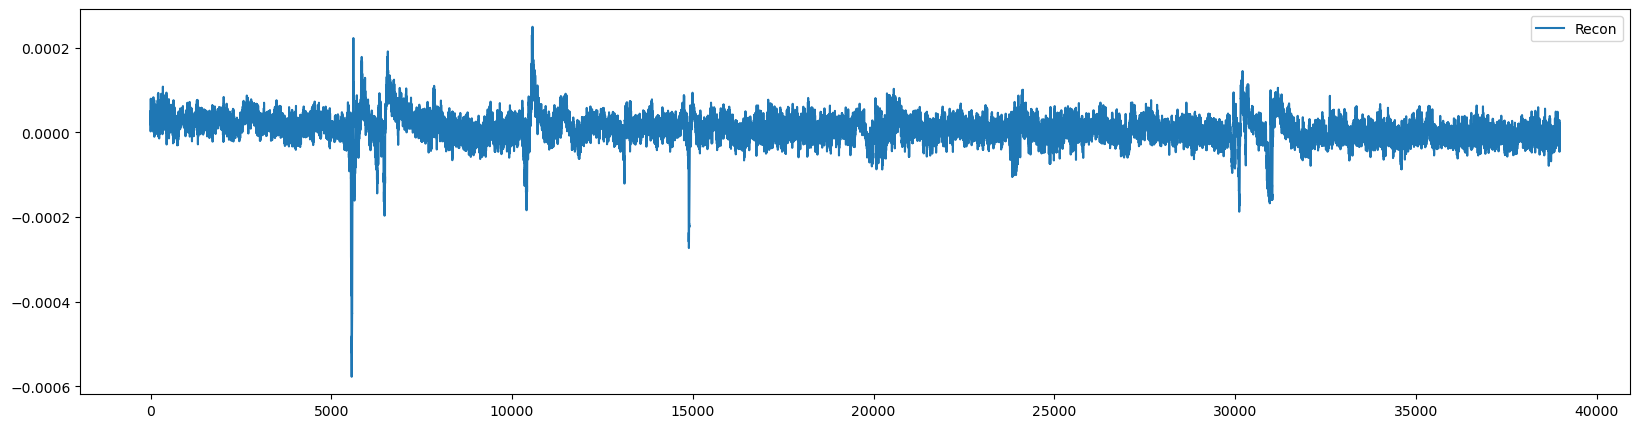

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(wavelet_recon[0], label=f'Recon')
plt.legend()
plt.show()

In [75]:
delta_recon = pywt.waverec([relevant_bands['delta'], None, None, None, None, None], wavelet='db4', axis=-1)
print(data_downsampled[0].shape)
print(delta_recon.shape)

(77952,)
(21, 77958)


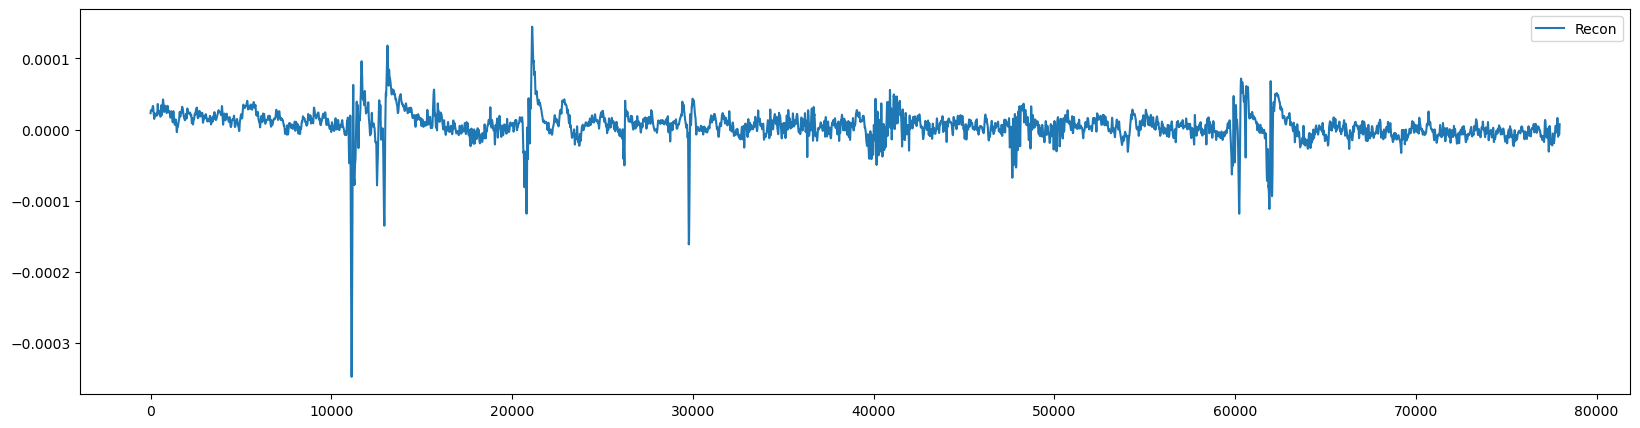

In [ ]:
plt.figure(figsize=(20, 5))
plt.plot(delta_recon[0], label=f'Recon')
plt.legend()
plt.show()

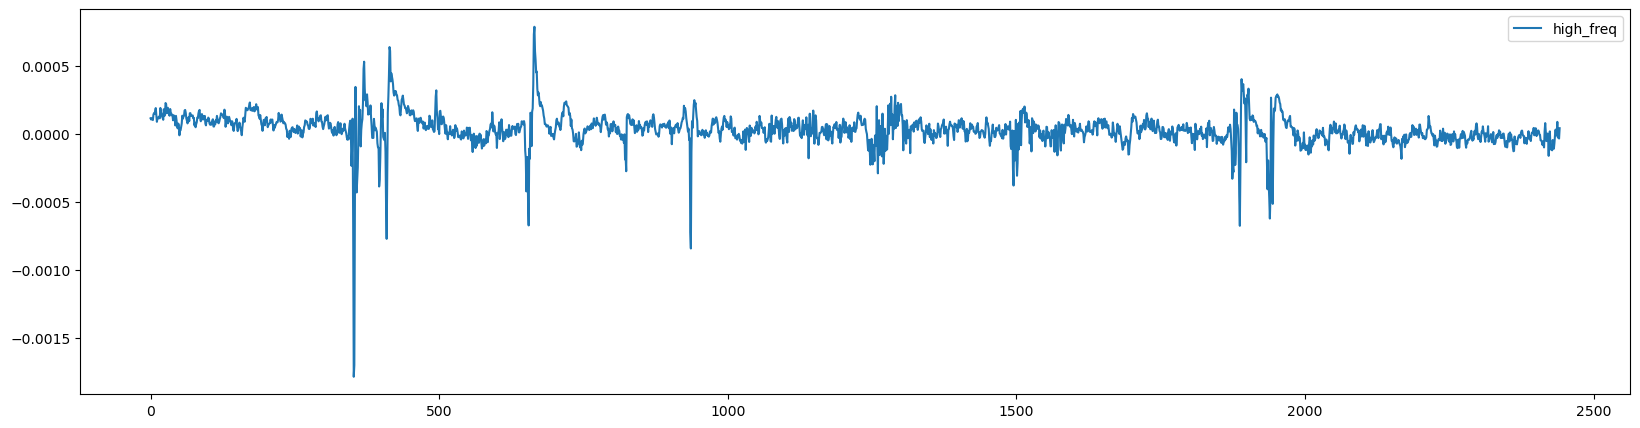

In [68]:
plt.figure(figsize=(20, 5))
plt.plot(relevant_bands['delta'][0], label=band)
plt.legend()
plt.show()

In [72]:
theta_recon = pywt.waverec([None, relevant_bands['theta'], None, None, None, None], wavelet='db4', axis=-1)
print(theta_recon.shape)

(21, 77958)


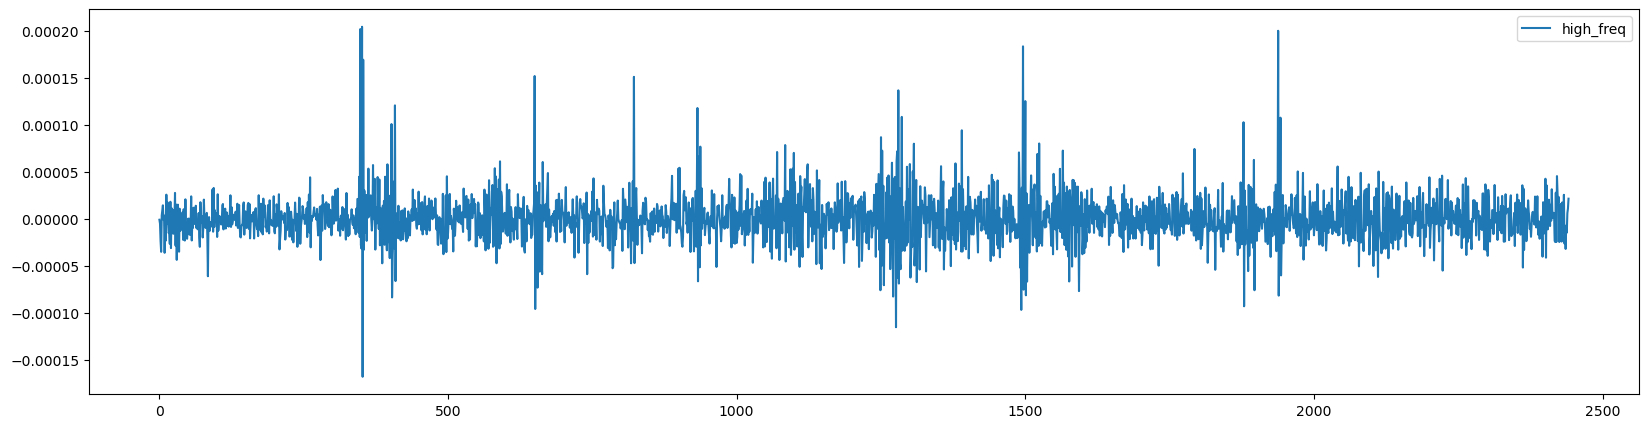

In [74]:
plt.figure(figsize=(20, 5))
plt.plot(relevant_bands['theta'][0], label=band)
plt.legend()
plt.show()

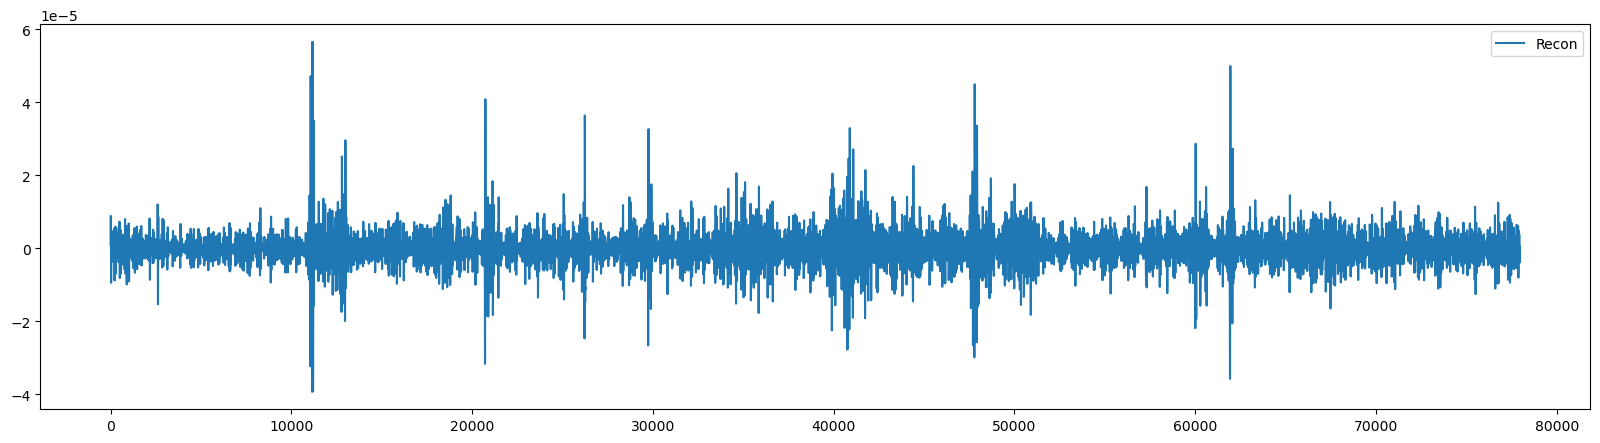

In [73]:
plt.figure(figsize=(20, 5))
plt.plot(theta_recon[0], label=f'Recon')
plt.legend()
plt.show()

In [83]:
delta_recon = pywt.waverec([relevant_bands['delta'], None, None, None, None, None], wavelet='db4', axis=-1)[:,:data_downsampled.shape[1]]
theta_recon = pywt.waverec([None, relevant_bands['theta'], None, None, None, None], wavelet='db4', axis=-1)[:,:data_downsampled.shape[1]]
alpha_recon = pywt.waverec([None, relevant_bands['alpha'], None, None, None], wavelet='db4', axis=-1)[:, :data_downsampled.shape[1]]
beta_recon = pywt.waverec([None, relevant_bands['beta'], None, None], wavelet='db4', axis=-1)[:,:data_downsampled.shape[1]]
gamma_recon = pywt.waverec([None, relevant_bands['gamma'], None], wavelet='db4', axis=-1)[:,:data_downsampled.shape[1]]
high_recon = pywt.waverec([None, relevant_bands['high_freq']], wavelet='db4', axis=-1)[:,:data_downsampled.shape[1]]

print(alpha_recon.shape, beta_recon.shape, gamma_recon.shape, high_recon.shape)

(21, 77952) (21, 77952) (21, 77952) (21, 77952)


In [91]:
recon = delta_recon + theta_recon + alpha_recon + beta_recon

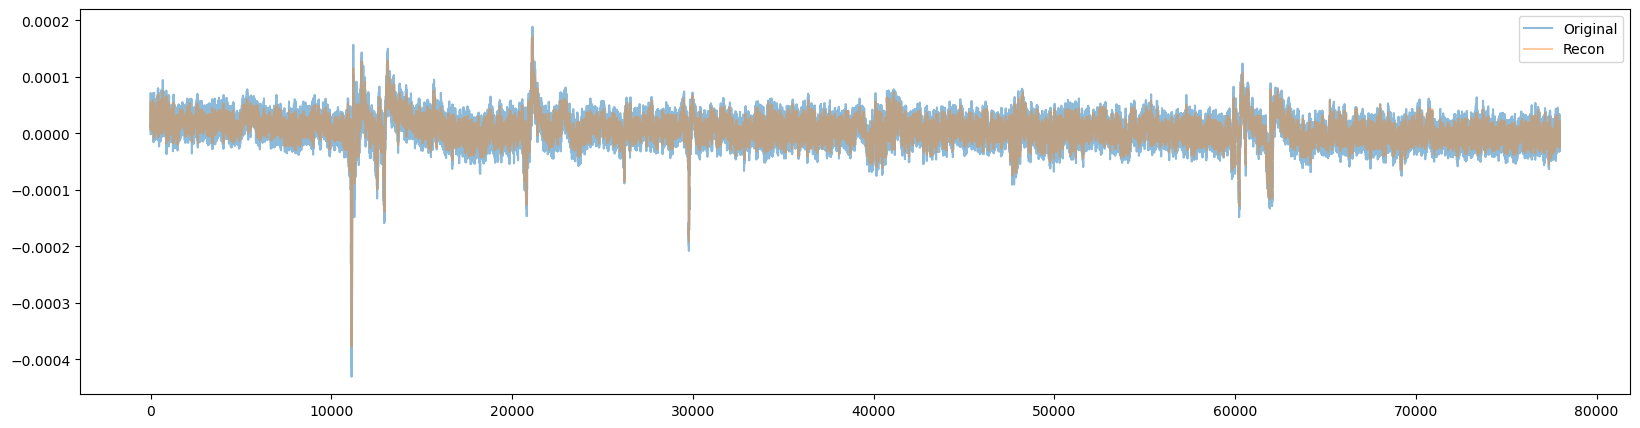

In [92]:
plt.figure(figsize=(20, 5))
plt.plot(data_downsampled[0, :], label=f'Original', alpha=0.5)
plt.plot(recon[0], label=f'Recon', alpha=0.4)
plt.legend()
plt.show()

In [99]:
import torch
import pickle
import argparse

In [100]:
class TUABLoader(torch.utils.data.Dataset):
    def __init__(self, root, files, sampling_rate=200):
        self.root = root
        self.files = files
        self.default_rate = 200
        self.sampling_rate = sampling_rate

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        sample = pickle.load(open(os.path.join(self.root, self.files[index]), "rb"))
        X = sample["X"]
        # from default 200Hz to ?
        if self.sampling_rate != self.default_rate:
            X = resample(X, 10 * self.sampling_rate, axis=-1)
        X = X / (
            np.quantile(np.abs(X), q=0.95, method="linear", axis=-1, keepdims=True)
            + 1e-8
        )
        Y = sample["y"]
        X = torch.FloatTensor(X)
        return X, Y

In [101]:
def prepare_TUAB_dataloader(args):
    # set random seed
    seed = 12345
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

    root = "/home/hice1/mchen439/scratch/eegtrue"

    train_files = os.listdir(os.path.join(root, "train"))
    np.random.shuffle(train_files)
    # train_files = train_files[:100000]
    val_files = os.listdir(os.path.join(root, "val"))
    test_files = os.listdir(os.path.join(root, "test"))

    print(len(train_files), len(val_files), len(test_files))

    # prepare training and test data loader
    train_loader = torch.utils.data.DataLoader(
        TUABLoader(os.path.join(root, "train"),
                   train_files, args.sampling_rate),
        batch_size=args.batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=args.num_workers,
        persistent_workers=True,
    )
    test_loader = torch.utils.data.DataLoader(
        TUABLoader(os.path.join(root, "test"), test_files, args.sampling_rate),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        persistent_workers=True,
    )
    val_loader = torch.utils.data.DataLoader(
        TUABLoader(os.path.join(root, "val"), val_files, args.sampling_rate),
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        persistent_workers=True,
    )
    print(len(train_loader), len(val_loader), len(test_loader))
    return train_loader, test_loader, val_loader

In [102]:
parser = argparse.ArgumentParser()
parser.add_argument("--epochs", type=int, default=100,
                    help="number of epochs")
parser.add_argument("--lr", type=float, default=1e-3, help="learning rate")
parser.add_argument("--weight_decay", type=float,
                    default=1e-5, help="weight decay")
parser.add_argument("--batch_size", type=int,
                    default=512, help="batch size")
parser.add_argument("--num_workers", type=int,
                    default=8, help="number of workers")
parser.add_argument("--dataset", type=str, default="TUAB", help="dataset")
parser.add_argument(
    "--model", type=str, default="SPaRCNet", help="which supervised model to use"
)
parser.add_argument(
    "--in_channels", type=int, default=16, help="number of input channels"
)
parser.add_argument(
    "--sample_length", type=float, default=10, help="length (s) of sample"
)
parser.add_argument(
    "--n_classes", type=int, default=1, help="number of output classes"
)
parser.add_argument(
    "--sampling_rate", type=int, default=200, help="sampling rate (r)"
)
parser.add_argument("--token_size", type=int,
                    default=200, help="token size (t)")
parser.add_argument(
    "--hop_length", type=int, default=100, help="token hop length (t - p)"
)
parser.add_argument(
    "--pretrain_model_path", type=str, default="", help="pretrained model path"
)
args, _ = parser.parse_known_args()

In [103]:
train_loader, test_loader, val_loader = prepare_TUAB_dataloader(args)

300823 71687 36945
587 141 73


In [104]:
data_iterator = iter(train_loader)
x, y = next(data_iterator)
print(x.shape, y.shape)

torch.Size([512, 16, 2000]) torch.Size([512])


In [106]:
data = x[0, 0].numpy()

<Figure size 2000x500 with 0 Axes>

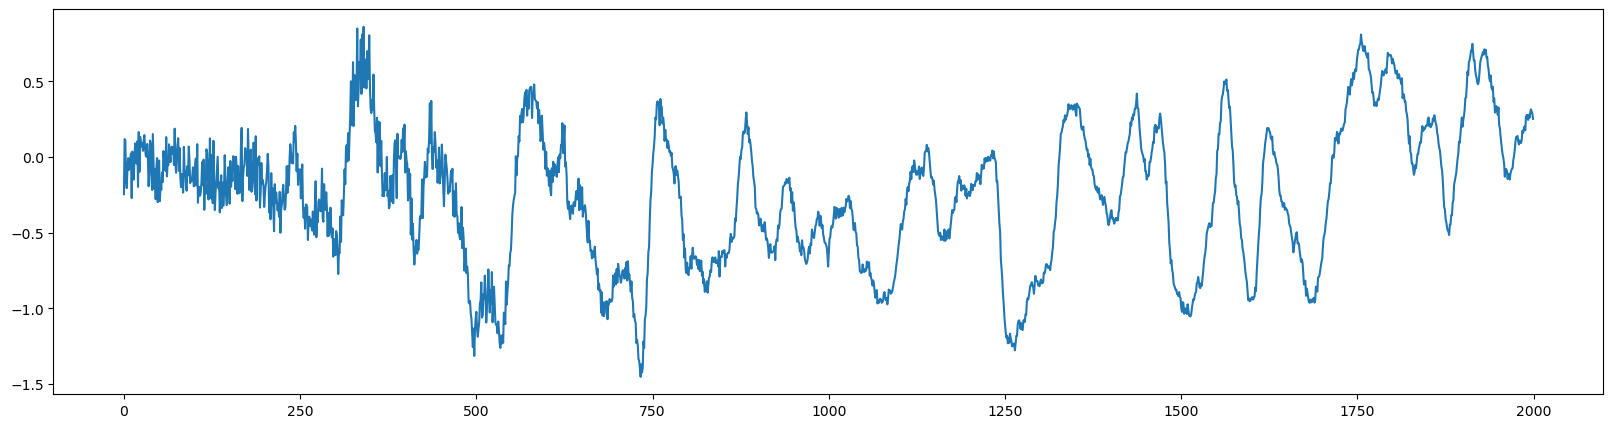

In [108]:
plt.figure(figsize=(20, 5))
plt.plot(data, label='original')
plt.show()

In [116]:
dbt = pywt.WaveletPacket(data, wavelet='db4', maxlevel=6, axis=-1)

relevant_bands = {
	'0': dbt['aaaaaa'].data, # 0 - 3.125Hz
	'1': dbt['aaaaad'].data, #3.125 - 6.25Hz
	'2': dbt['aaaad'].data, # 6 - 12Hz
	'3': dbt['aaad'].data, # 6 - 12Hz
	'4': dbt['aad'].data, # 12-25Hz
	'5': dbt['ad'].data, # 50-100Hz 
	#'6': dbt['d'].data # 100-200Hz
}

In [117]:
for band, data in relevant_bands.items():
	print(band, data.shape)

0 (22,)
1 (22,)
2 (38,)
3 (69,)
4 (131,)
5 (256,)


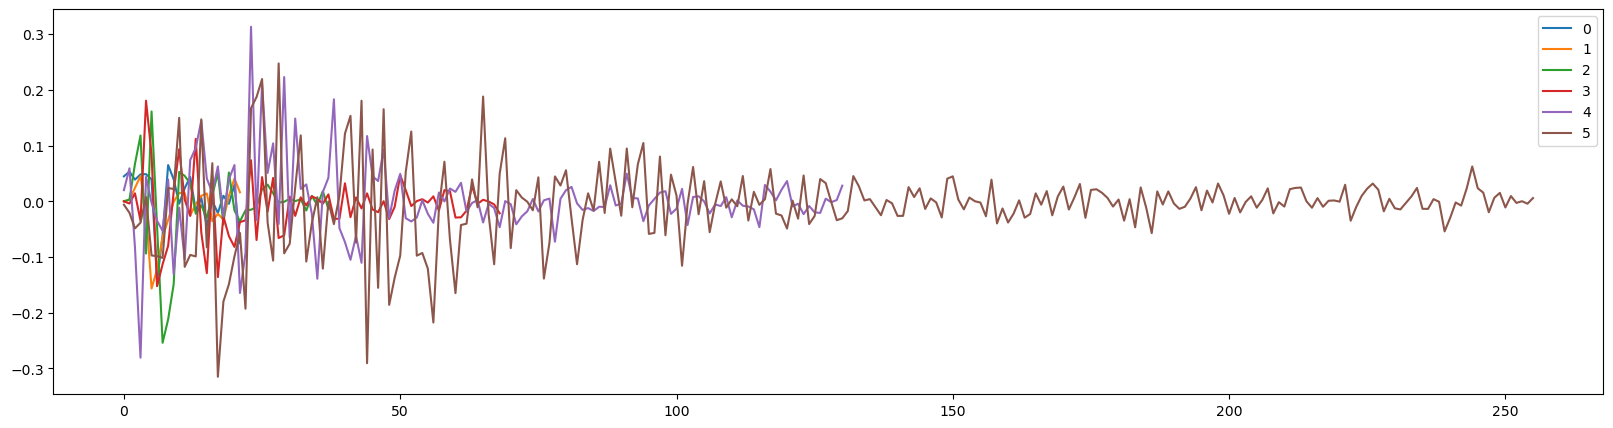

In [118]:
plt.figure(figsize=(20, 5))
for band, data in relevant_bands.items():
	plt.plot(data, label=band)
plt.legend()
plt.show()

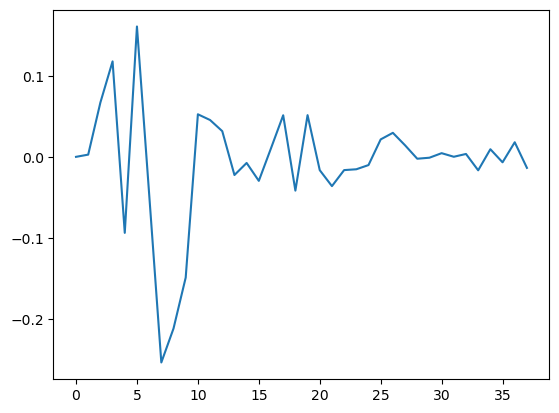

In [121]:
plt.plot(relevant_bands['2'])
plt.show()